# Homework 2

## Problem 1 -  Dollar Profits
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- dollarpos variable below is a DataFrame containing randomly generated initial dollar positions in each symbol at the close of market the prior day. 
- Compute the dollar profit in each symbol on a given day as a DataFrame
- Plot the cumulative dollar profit in A through time

In [1]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

dollarpos = np.random.normal(1000,100, (1000,5))
dollarpos = pd.DataFrame(dollarpos,columns = columns).abs()

<Axes: title={'center': 'Cumulative Profit for Asset A'}>

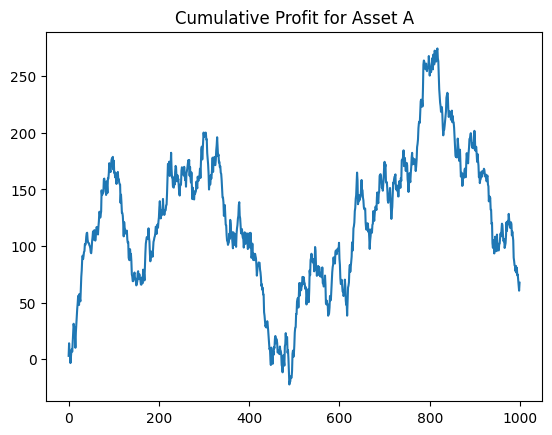

In [6]:
cumulative_profit = (rets * dollarpos).cumsum()
cumulative_profit["A"].plot(title="Cumulative Profit for Asset A")

## Problem 2 - Performance Stats 
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols.
- Please complete the function "compute_stats".
- compute_stats takes as input rets and returns a new DataFrame (stats) containing performance stats as specified below. rows of the result should be symbols and columns the performance stat label.
    1. "avg": average return (annualized)
    2. "vol": volatility (annualized)
    3. "sharpe": sharpe ratio (annualzied)
    4. "hit_rate": percent of returns which are positive
- Plot the sharpe ratios in "stats" in ascending order.

In [14]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [15]:
def compute_stats(rets):
    # fill out the body here
    # return a DataFrame "stats"
    # columns should be performance stat label
    # rows should be symbols
    mean_returns = rets.mean() * 252
    vol_returns = rets.std() * np.sqrt(252)
    sharpe_ratio = mean_returns / vol_returns
    hit_rate = (rets > 0).count()
    stats = pd.DataFrame({
        'Mean Return': mean_returns,
        'Volatility': vol_returns,
        'Sharpe Ratio': sharpe_ratio,
        'Hit Rate': hit_rate
    })
    return stats

In [16]:
compute_stats(rets)

,Mean Return,Volatility,Sharpe Ratio,Hit Rate
A,0.028730,0.101799,0.282224,1000
B,0.120800,0.099772,1.210766,1000
C,0.018690,0.103599,0.180409,1000
D,0.051331,0.100662,0.509934,1000
E,0.013511,0.101800,0.132720,1000


## Problem 3 - Simple Reversal Signal
- "rets" variable below is a DataFrame containing randomly generated, hypothetical daily returns. Rows represent days and columns represent symbols
- Please complete the function "reversal_signal"
- reversal_signal takes as input rets and returns a new DataFrame (signal) which has the same rows/columns as rets. The values of signal are 1 if the symbol had the worst return that day, -1 if it had the best return, and 0 otherwise. 
- plot the value of signal through time for "A"

Hint: Try to construct a boolean DataFrame first and then convert it to an integer DataFrame

In [17]:
import numpy as np 
import pandas as pd 

np.random.seed(5)
rets = np.random.normal(0.05/252,0.1/np.sqrt(252), (1000,5))
columns = ['A','B','C','D','E']
rets = pd.DataFrame(rets,columns = columns)

In [18]:
def reversal_signal(rets):
    # fill out the body here
    # return a DataFrame "signal"
    # signal has same index/columns as rets
    # the value in signal is  1 if the symbol had the worst return on
    # a particular day, -1 if it had the best, and 0 otherwise
    signal = (
    rets.where(rets.ne(rets.max(axis=1), axis=0), -1)
      .where(rets.ne(rets.min(axis=1), axis=0), 1)
      .fillna(0)
)
    return signal

<Axes: title={'center': 'Reversal Signal for Asset A'}>

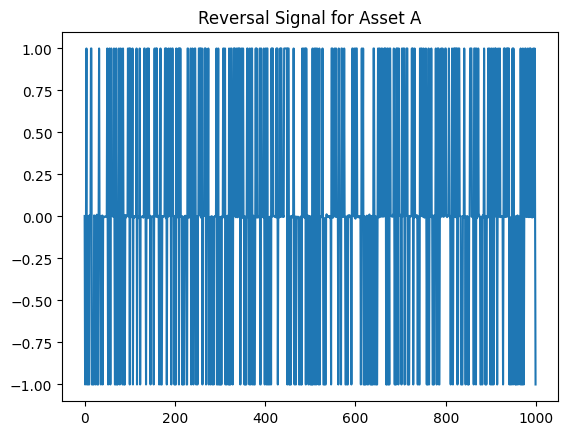

In [22]:
signal = reversal_signal(rets)
signal['A'].plot(title="Reversal Signal for Asset A")